# Clickable Fixation Topoplot Prototype

This notebook is intentionally prototype-only.

- fixation dataset only
- `sort_var = :duration` only
- no CNN training yet
- instead: a small handcrafted feature vector plus dummy `sigmoid` weights to emulate a captured output layer
- clicking a channel updates the duration-sorted ERP image on the right
- the ERP image uses the asymmetric zero-anchored colorbar from `notebooks/utils/erp_image_utils.jl`


In [1]:
import Pkg

week15_dir = if isfile(joinpath(pwd(), "topoplots.ipynb")) && isfile(joinpath(pwd(), "..", "model_test", "Project.toml"))
    pwd()
else
    candidate = joinpath(pwd(), "notebooks", "week_15")
    @assert isfile(joinpath(candidate, "topoplots.ipynb")) "Could not locate notebooks/week_15 from current working directory."
    candidate
end

model_test_dir = normpath(joinpath(week15_dir, "..", "model_test"))
cd(week15_dir)
Pkg.activate(model_test_dir)

if !isdefined(Main, :Week15TryNewData)
    include(joinpath(week15_dir, "try_new_data_helpers.jl"))
end
if !isdefined(Main, :Week15Topoplots)
    include(joinpath(week15_dir, "topoplots_helpers.jl"))
end

using .Week15TryNewData
using .Week15Topoplots
using DataFrames

backend = Week15Topoplots.activate_topoplot_backend!()

println("Week-15 directory: ", week15_dir)
println("Active project: ", Base.active_project())
println("Makie backend: ", backend)
nothing


  Activating project at `~/Dokumente/BA2/notebooks/model_test`
┌ Warning: WGLMakie is unavailable. Falling back to CairoMakie. The figure renders, but click interaction needs WGLMakie or GLMakie.
│   exception = (UndefVarError(:WGLMakie, 0x0000000000009a93, Main.Week15Topoplots), Union{Ptr{Nothing}, Base.InterpreterIP}[Ptr{Nothing}(0x00007fea7f2d835a), Ptr{Nothing}(0x00007fe9d2d6303d), Ptr{Nothing}(0x00007fe9d2d6312f), Ptr{Nothing}(0x00007fea7f276444), Ptr{Nothing}(0x00007fea7f275d34), Ptr{Nothing}(0x00007fea7f276a23), Ptr{Nothing}(0x00007fea7f277c62), Base.InterpreterIP in top-level CodeInfo for Main at statement 4, Ptr{Nothing}(0x00007fea7f295742), Ptr{Nothing}(0x00007fea7f295bf1), Ptr{Nothing}(0x00007fea7f2964f5), Ptr{Nothing}(0x00007fea7f296b31), Ptr{Nothing}(0x00007fea6dd97782), Ptr{Nothing}(0x00007fe9d2d498ee), Ptr{Nothing}(0x00007fea7f264b3a), Ptr{Nothing}(0x00007fe9d2d46dde), Ptr{Nothing}(0x00007fe9d2d48a98), Ptr{Nothing}(0x00007fe9d2d4920c), Ptr{Nothing}(0x00007fe9d2d492b2), P

Week-15 directory: /home/benjamin/Dokumente/BA2/notebooks/week_15
Active project: /home/benjamin/Dokumente/BA2/notebooks/model_test/Project.toml
Makie backend: CairoMakie


## Usage

Run the next cell once to build the fixation-only `duration` context for all 128 channels.
The last cell renders the topoplot.

If the figure appears only as a static image in your notebook, re-open the notebook with the `WGLMakie` backend active and re-run the setup cell.


In [2]:
ctx = Week15Topoplots.build_fixation_duration_topoplot_context(
    target_size = (64, 64),
    lowpass = true,
)

top_channels_df = first(
    sort(
        select(ctx.score_df, :channel, :channel_name, :p_sigmoid, :dummy_sigmoid_logit, :dummy_label),
        :p_sigmoid;
        rev = true,
    ),
    12,
)

display(top_channels_df)
nothing


Row,channel,channel_name,p_sigmoid,dummy_sigmoid_logit,dummy_label
,Int64,String,Float64,Float64,String
1,67,ch067,0.956483,3.0901,sigmoid
2,47,ch047,0.94873,2.91802,sigmoid
3,61,ch061,0.947336,2.88973,sigmoid
4,18,ch018,0.893012,2.12188,sigmoid
5,13,ch013,0.877483,1.9688,sigmoid
6,105,ch105,0.872886,1.92672,sigmoid
7,87,ch087,0.859798,1.81361,sigmoid
8,20,ch020,0.859497,1.81112,sigmoid
9,110,ch110,0.844667,1.69337,sigmoid


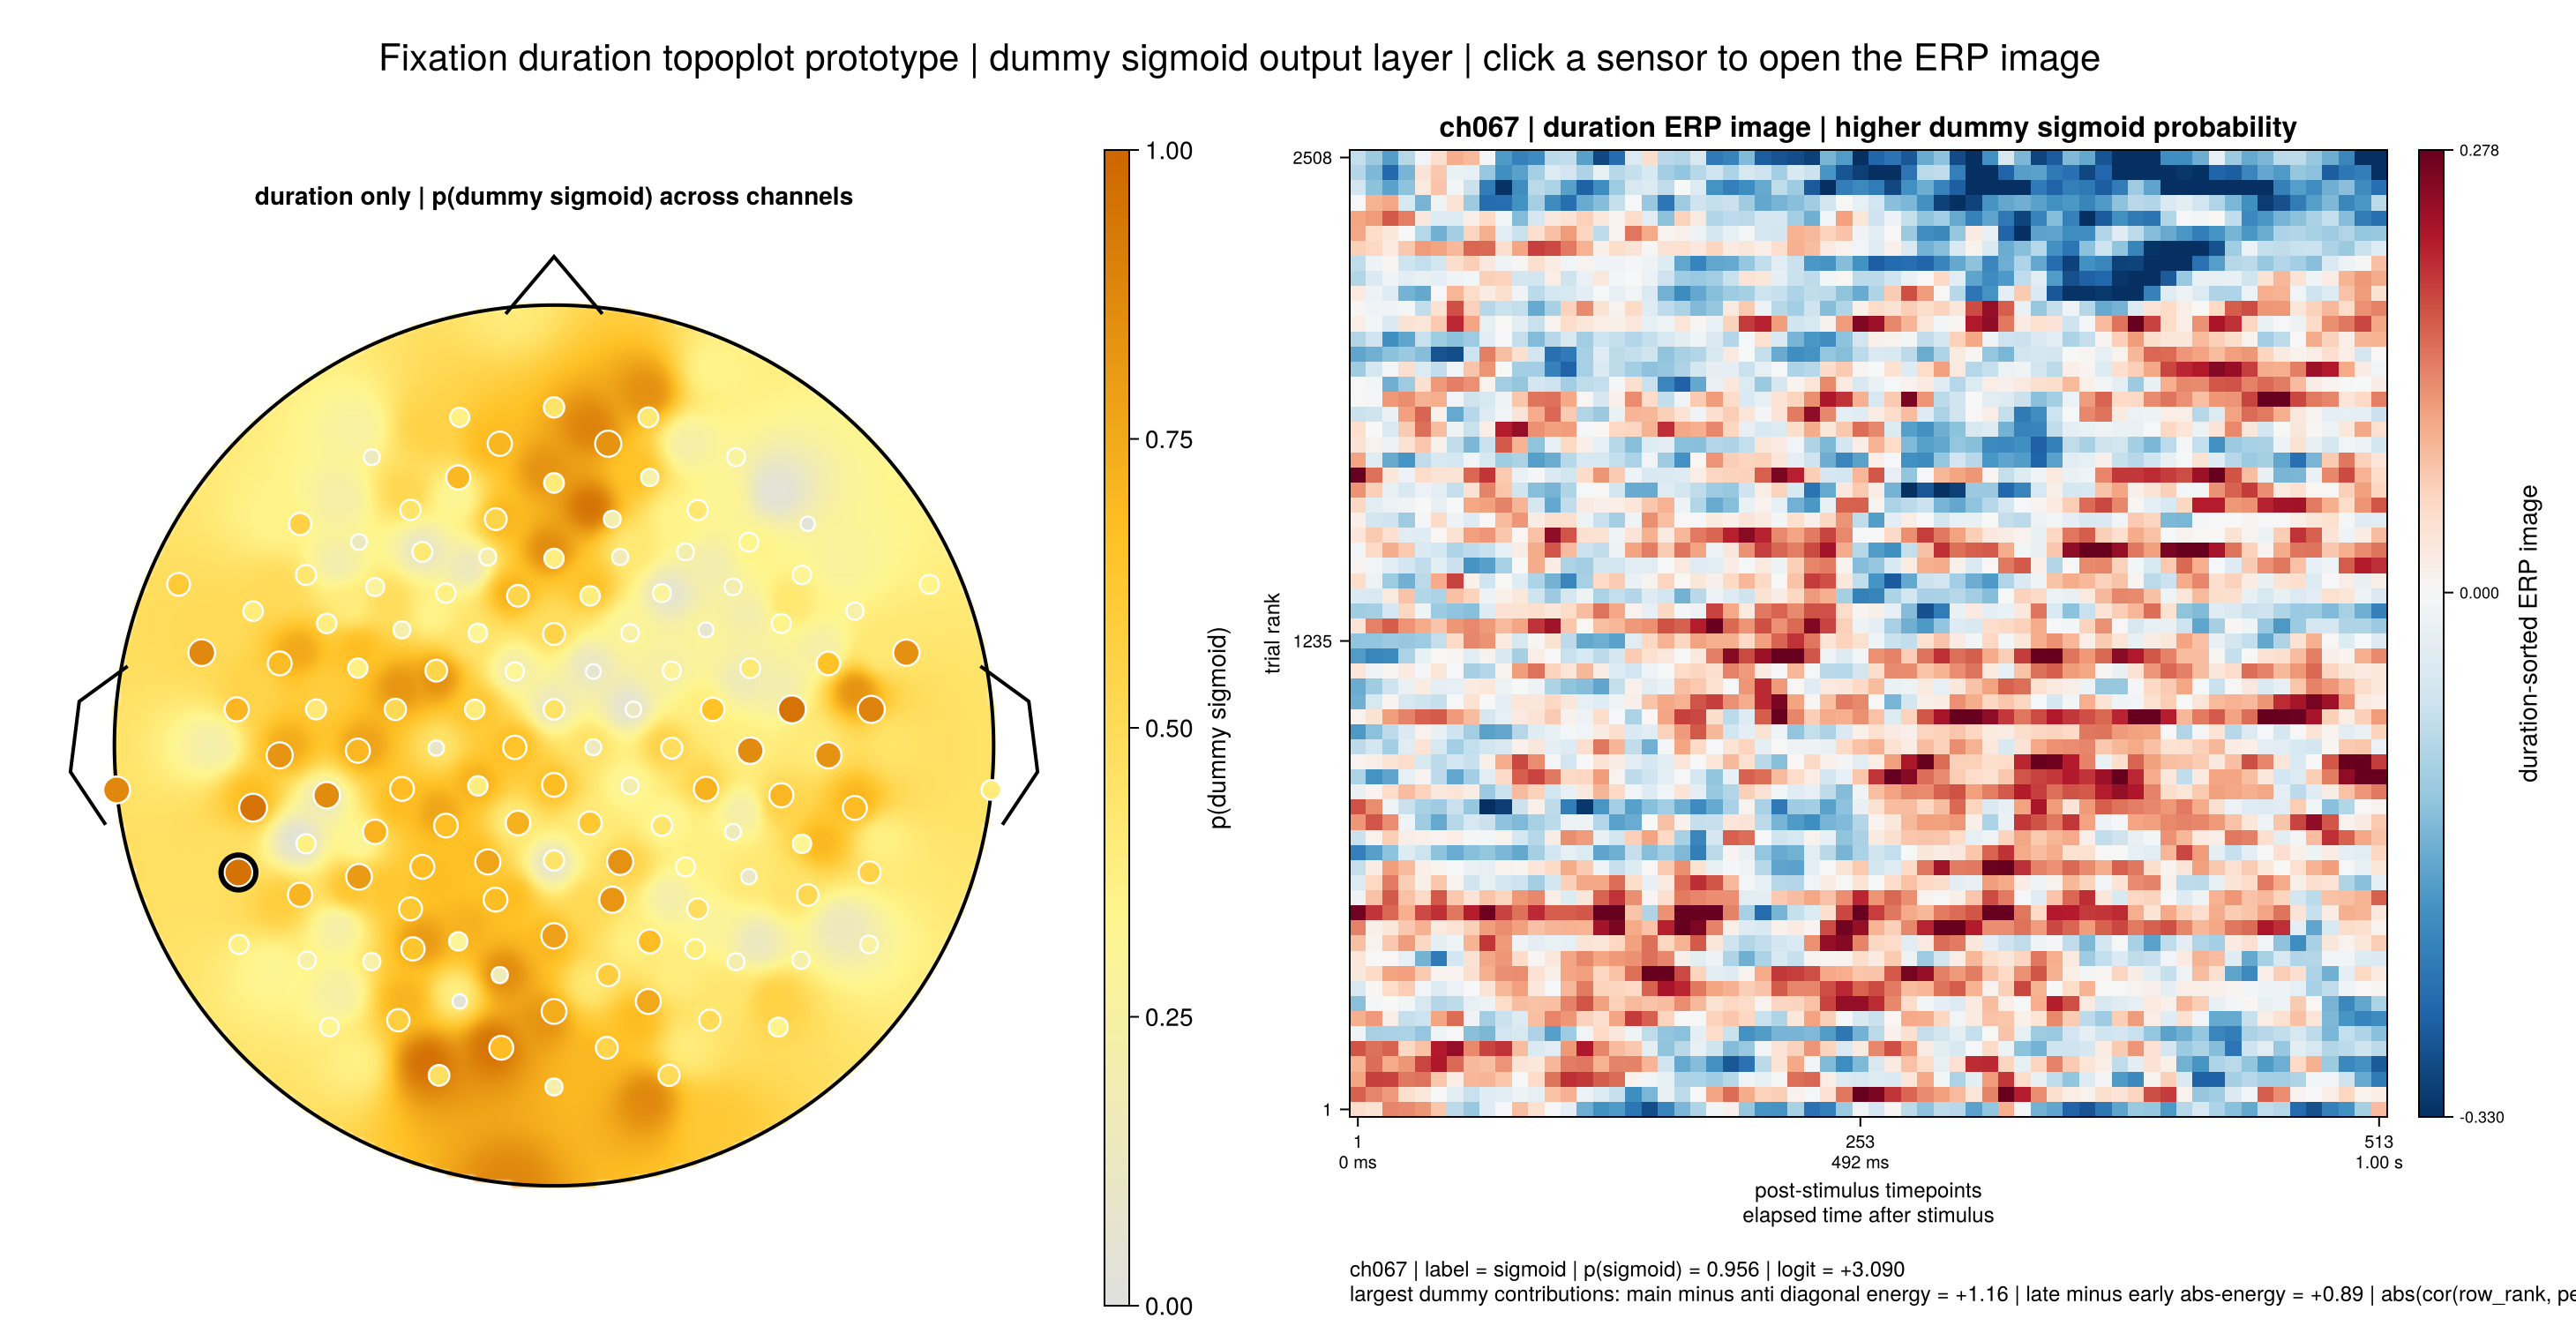

In [3]:
topo = Week15Topoplots.plot_fixation_duration_topoplot(ctx)
topo.figure
